(614, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


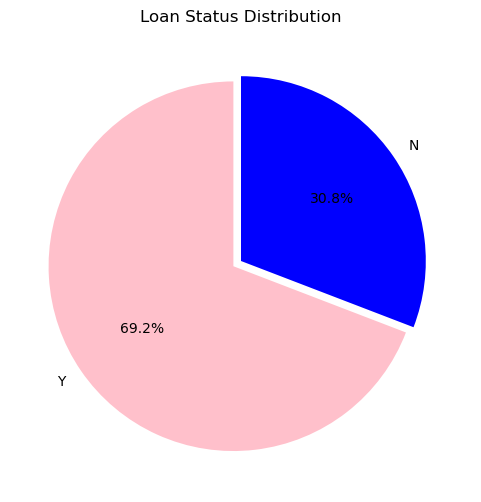

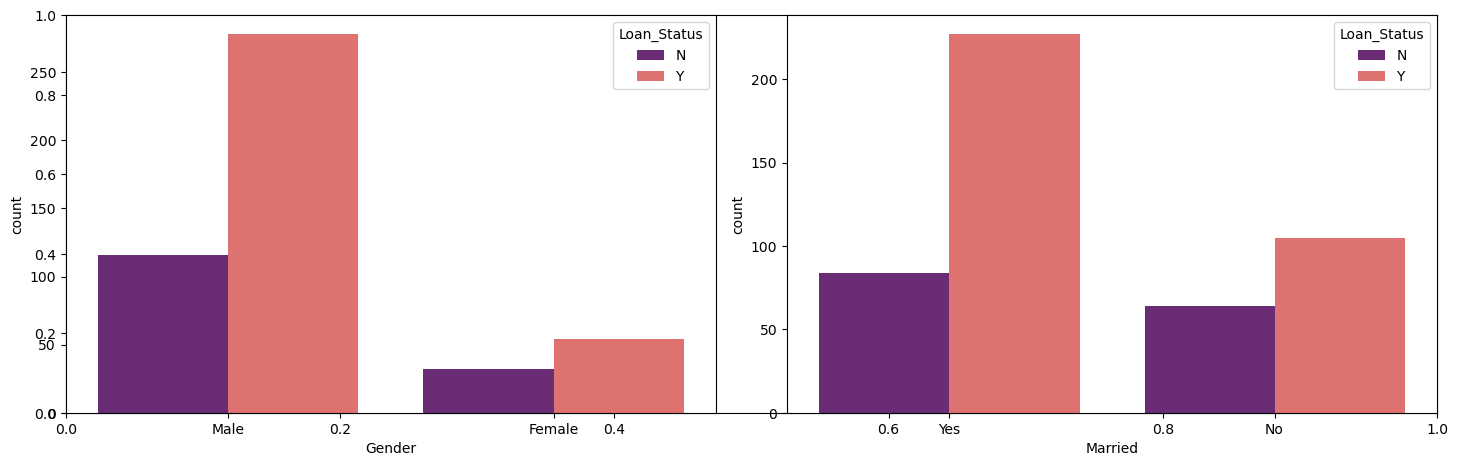

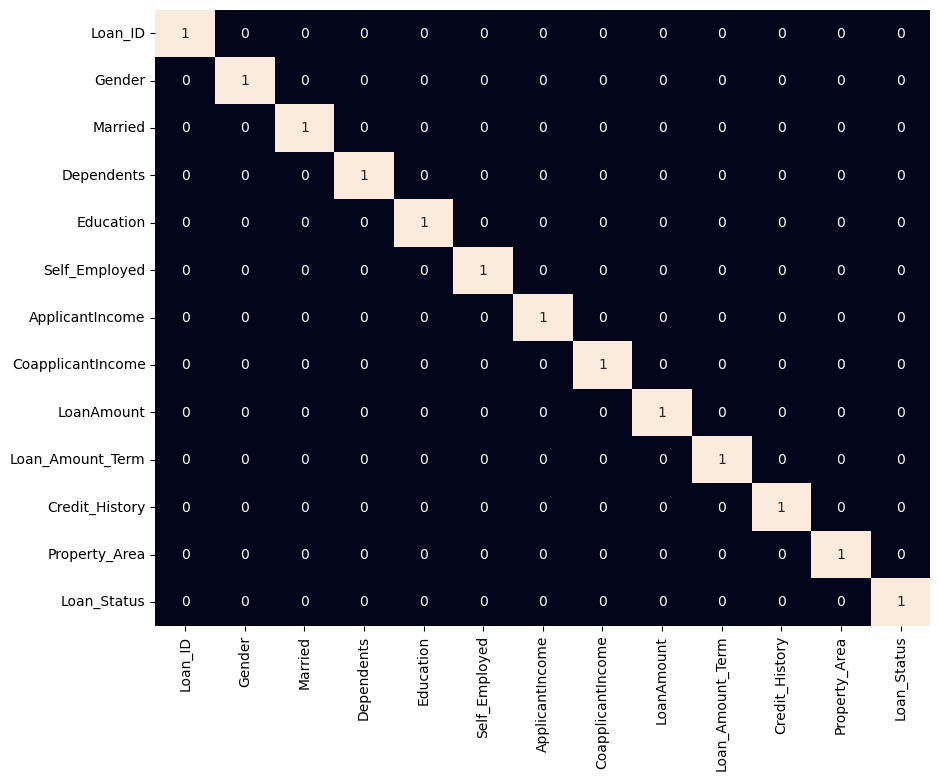

Training ROC AUC Score: 0.8543307086614174
Validation ROC AUC Score: 0.7136904761904762

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.54      0.58        24
           1       0.85      0.89      0.87        70

    accuracy                           0.80        94
   macro avg       0.73      0.71      0.72        94
weighted avg       0.79      0.80      0.79        94



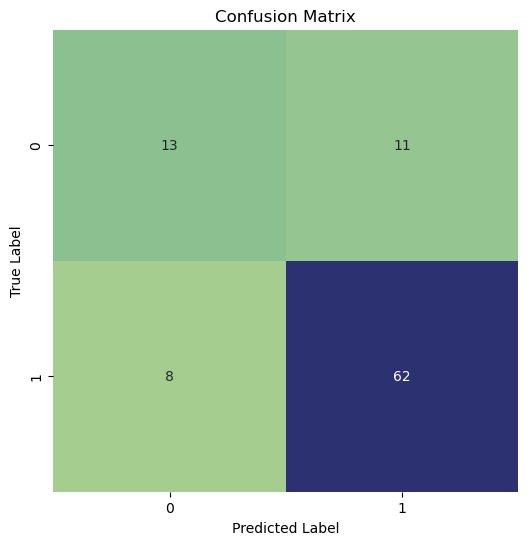

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.svm import SVC
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv('loan_data.csv')


print(df.shape)
df.info()


df = df.dropna() 

pie_colors = ['pink', 'blue'] 

temp = df['Loan_Status'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(temp.values, 
        labels=temp.index, 
        autopct='%1.1f%%', 
        colors=pie_colors,  
        startangle=90, 
        explode=(0.05, 0)) 
plt.title('Loan Status Distribution')
plt.show()

# Countplots for Categorical Columns
plt.subplots(figsize=(15, 5))
for i, col in enumerate(['Gender', 'Married']):
    plt.subplot(1, 2, i+1)
    sb.countplot(data=df, x=col, hue='Loan_Status', palette='magma') # Changed color palette here
plt.tight_layout()
plt.show()

# 3. Handling Outliers

df = df[df['ApplicantIncome'] < 25000]
df = df[df['LoanAmount'] < 400] 

# 4. Data Preprocessing
def encode_labels(data):
   
    data_encoded = data.copy()
    for col in data_encoded.columns:
        if data_encoded[col].dtype == 'object':
            le = LabelEncoder()
            data_encoded[col] = le.fit_transform(data_encoded[col])
    return data_encoded

df = encode_labels(df)

# Correlation Heatmap
plt.figure(figsize=(10, 8))
sb.heatmap(df.corr() > 0.8, annot=True, cbar=False)
plt.show()

# 5. Model Preparation
features = df.drop('Loan_Status', axis=1) 
target = df['Loan_Status'].values 

X_train, X_val, Y_train, Y_val = train_test_split(
    features, target, test_size=0.2, random_state=10
) 

# Handle Imbalance
ros = RandomOverSampler(sampling_strategy='minority', random_state=0) 
X_resampled, Y_resampled = ros.fit_resample(X_train, Y_train) 

# Scaling
scaler = StandardScaler()
X_resampled = scaler.fit_transform(X_resampled)
X_val = scaler.transform(X_val)

# 6. Model Training and Evaluation
model = SVC(kernel='rbf', probability=True) 
model.fit(X_resampled, Y_resampled)

# Predictions
train_preds = model.predict(X_resampled)
val_preds = model.predict(X_val)

print('Training ROC AUC Score:', roc_auc_score(Y_resampled, train_preds))
print('Validation ROC AUC Score:', roc_auc_score(Y_val, val_preds))
print('\nClassification Report:\n', classification_report(Y_val, val_preds))

# 7. Final Visualization: Confusion Matrix
cm = confusion_matrix(Y_val, val_preds)
plt.figure(figsize=(6, 6))
sb.heatmap(cm, annot=True, fmt='d', cmap='crest', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()